In [ ]:
import json
import os
import pandas as pd
import numpy as np

DATA_DIR = '../input/competitions/cassava-leaf-disease-classification/'


with open(os.path.join(DATA_DIR, 'label_num_to_disease_map.json')) as f:
    disease_map = json.load(f)

print(disease_map)

print("--- 질병 라벨(0~4)의 실제 이름 ---")
for num, name in disease_map.items():
    print(f"라벨 {num}: {name}")
    
print("\n")

df = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))

# 숫자로 된 label을 실제 질병 이름으로 바꾼 열을 하나 더 추가
df['disease_name'] = df['label'].astype(str).map(disease_map)

print("--- train.csv 첫 5줄 확인 ---")
print(df.head())

{'0': 'Cassava Bacterial Blight (CBB)', '1': 'Cassava Brown Streak Disease (CBSD)', '2': 'Cassava Green Mottle (CGM)', '3': 'Cassava Mosaic Disease (CMD)', '4': 'Healthy'}
--- 질병 라벨(0~4)의 실제 이름 ---
라벨 0: Cassava Bacterial Blight (CBB)
라벨 1: Cassava Brown Streak Disease (CBSD)
라벨 2: Cassava Green Mottle (CGM)
라벨 3: Cassava Mosaic Disease (CMD)
라벨 4: Healthy


--- train.csv 첫 5줄 확인 ---
         image_id  label                         disease_name
0  1000015157.jpg      0       Cassava Bacterial Blight (CBB)
1  1000201771.jpg      3         Cassava Mosaic Disease (CMD)
2   100042118.jpg      1  Cassava Brown Streak Disease (CBSD)
3  1000723321.jpg      1  Cassava Brown Streak Disease (CBSD)
4  1000812911.jpg      3         Cassava Mosaic Disease (CMD)


In [4]:
print("--- 질병별 개수 확인 ---")
print(df['disease_name'].value_counts())

--- 질병별 개수 확인 ---
disease_name
Cassava Mosaic Disease (CMD)           13158
Healthy                                 2577
Cassava Green Mottle (CGM)              2386
Cassava Brown Streak Disease (CBSD)     2189
Cassava Bacterial Blight (CBB)          1087
Name: count, dtype: int64


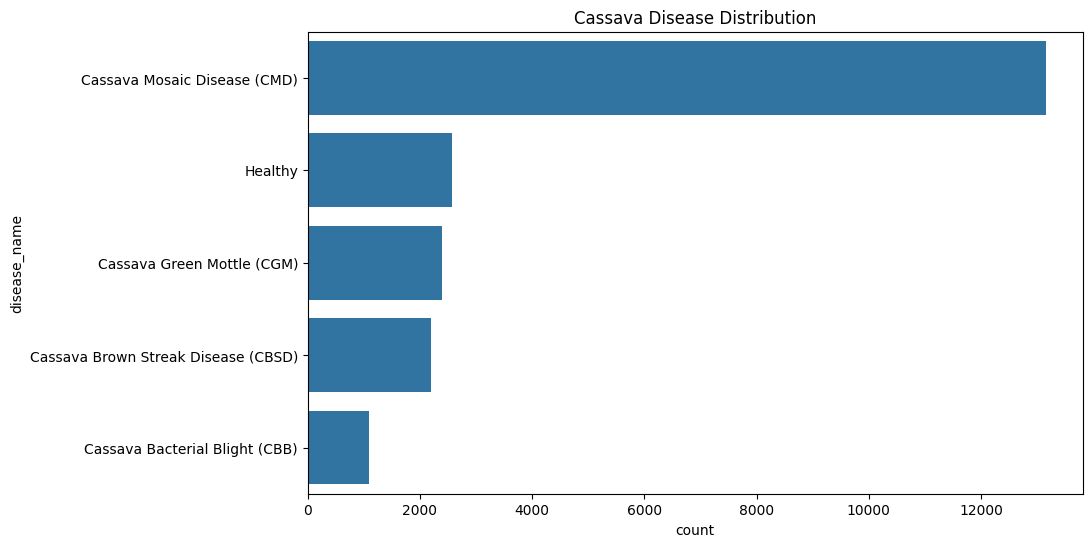

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# 질병별 개수 시각화
plt.figure(figsize=(10, 6))
sns.countplot(y=df['disease_name'], order=df['disease_name'].value_counts().index)
plt.title('Cassava Disease Distribution')
plt.show()

## 클래스 불균형 발생

CMD의 데이터가 13158개로 다른 클래스보다 압도적으로 많음

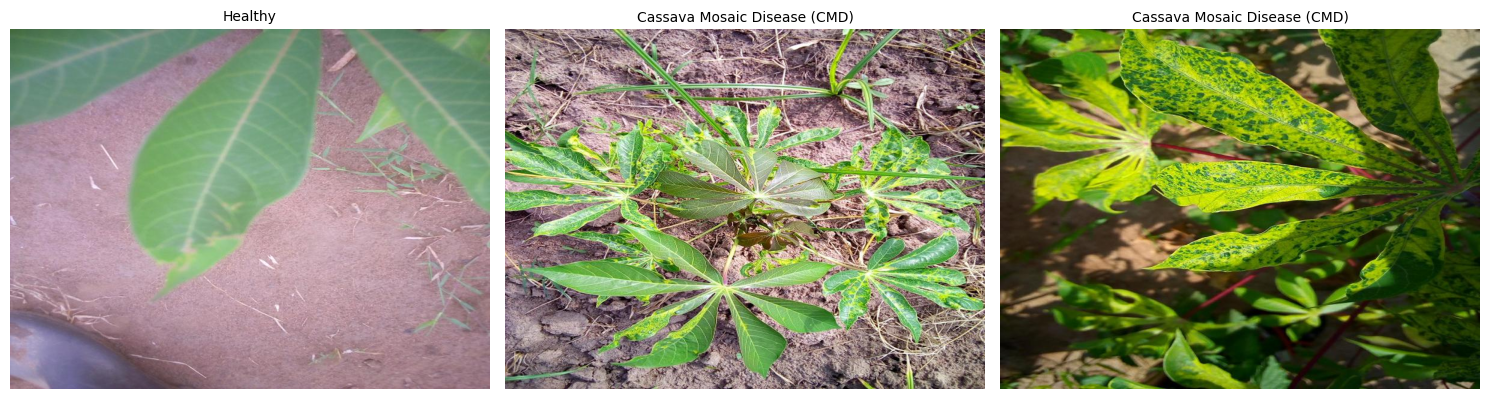

In [6]:
# 데이터 이미지로 확인

import cv2

# 무작위로 3장 추출
sample_df = df.sample(3, random_state=42).reset_index(drop=True)

plt.figure(figsize=(15, 12))
for i in range(3):
    # 사진 파일 이름과 병 이름 가져오기
    image_name = sample_df.loc[i, 'image_id']
    disease_name = sample_df.loc[i, 'disease_name']
    
    # 사진 읽어오기
    image_path = os.path.join(DATA_DIR, 'train_images', image_name)
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # 색상 보정
    
    # 화면에 그리기
    plt.subplot(1, 3, i + 1)
    plt.imshow(image)
    plt.title(disease_name, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [7]:
# 결측치 확인

print(df.isnull().sum())

image_id        0
label           0
disease_name    0
dtype: int64


In [8]:
# 원본 이미지 크기 샘플 확인

img_name = df.loc[0, 'image_id']
img_path = os.path.join(DATA_DIR, 'train_images', img_name)
img = cv2.imread(img_path)
    
print(f"{img_name}의 크기: {img.shape}")

1000015157.jpg의 크기: (600, 800, 3)
